In [ ]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names

# 示例使用
folder_path = r'C:\Users\ASUS\Desktop\研一（下）\dlnlp\第三次大作业\jyxstxtqj_downcc.com'
contents, names = read_txt_files_with_different_encodings(folder_path)

for items in contents:
    print("文件内容:", items[500:1000])
print("文件标题:", names)

文件内容: 个剑客的故事我知道得不全。但反正是写小说，不知道原来出典的，不妨任意创造一个故事。可是连写三十三个剑侠故事的心愿，永远也完成不了的。写了第一篇《越女剑》后，第二篇《虬髯客》的小说就写不下去了。写叙述文比写小说不费力得多，于是改用平铺直叙的方式，介绍原来的故事。其中《虬髯客》、《聂隐娘》、《红线》、《昆仑奴》四个故事众所周知，不再详细叙述，同时原文的文笔极好，我没有能力译成同样简洁明丽的语体文，所以附录了原文。比较生僻的故事则将原文内容全部写了出来。这些短文写于一九七○年一月和二月，是为《明报晚报》创刊最初两个月所作。
　　一 赵处女
　　江苏与浙江到宋朝时已渐渐成为中国的经济与文化中心，苏州、杭州成为出产文化和美女的地方。但在春秋战国时期，吴人和越人却是勇决剽悍的象征。那样的轻视生死，追求生命中最后一刹那的光彩，和现代一般中国人的性格相去是这么遥远，和现代苏浙人士的机智柔和更是两个极端。在那时候，吴人越人血管中所流动的，是原始的、犷野的热血。吴越的文化是外来的。伍子胥、文种、范蠡都来自西方的楚国。勾践的另一个重要谋士计然来自北方的晋国。只有西施本色的美丽，才原来就属于浣纱溪那清澈的
文件内容: 这玩意儿比甚么游戏都好玩，转到门口，推门进去，大叫：“老师，你教我这玩意儿！”
　　这女孩儿李沅芷是总兵李可秀的独生女儿，是他在湘西做参将任内所生，给女儿取这名字，是纪念生地之意。教书先生陆高止是位饱学宿儒，五十四五岁年纪，平日与李沅芷谈古论今，师生间倒也甚是相得。这一天陆高止因受不了青蝇苦扰，发射芙蓉金针，钉死了数十只，哪知却给女弟子在窗外偷看到了。他见李沅芷一张清秀明艳的脸蛋红扑扑地显得甚是兴奋，当下淡淡的道：“唔，怎么不跟女伴去玩儿，想听诸葛亮三气周瑜的故事，是不是？”李沅芷道：“老师，你教我这好玩的法儿？”陆高止道：“甚么法儿呀？”
　　李沅芷道：“用金针钉苍蝇的法儿。”说着搬了张椅子，纵身跳上，细细瞧了一会，把钉在苍蝇身上的金针一枚枚拔下来，用纸抹拭干净，交还老师，说道：“老师，我知道，你这不是玩意儿，是非常高明的武功，你非教我不可。”她有时跟随父亲在练武场上盘马弯弓，也学过一些武艺。陆高止微笑道：“你要学武功，扶风城周围几百里地，谁也及不上你爹爹武艺高强。”李沅芷道：“我爹爹只会用弓箭射鹰，可不会用金针射苍蝇，你若不信，我便问爹爹去，看他会不会。”
　

In [2]:
import jieba
import re
import os

def load_custom_words(file_list):
    """加载自定义词汇（人名、地名等）到jieba分词词库"""
    for file in file_list:
        if os.path.exists(file):
            with open(file, 'r', encoding='utf-8') as f:
                for line in f:
                    word = line.strip()
                    if word:
                        jieba.add_word(word, freq=100000, tag='n')

def load_filter_items(file):
    """加载需要过滤的标点符号或停用词"""
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            return set(line.strip() for line in f if line.strip())
    return set()

def clean_text(text):
    """去除英文字符"""
    return re.sub(r'[a-zA-Z]', '', text)

def segment_novel(novel_text, punctuation_set, stopwords_set):
    """对单篇小说进行分词处理"""
    # 清洗文本
    cleaned_text = clean_text(novel_text)
    
    # 使用jieba进行分词
    words = jieba.lcut(cleaned_text)
    
    # 过滤标点符号和停用词
    filtered_words = [
        word for word in words 
        if word not in punctuation_set 
        and word not in stopwords_set
        and word.strip()
    ]
    
    return filtered_words

def process_jinyong_novels(novel_texts):
    """处理金庸小说列表"""
    # 加载自定义词汇
    custom_files = ["地名.txt", "人名.txt", "门派.txt", "武功.txt", "武器.txt"]
    load_custom_words(custom_files)
    
    # 加载需要过滤的内容
    punctuation_set = load_filter_items("cn_punctuation.txt")
    stopwords_set = load_filter_items("cn_stopwords.txt")
    i=0
    lll=len(novel_texts)
    # 处理每篇小说
    segmented_novels = []
    for novel_text in novel_texts:
        if i % 2 ==0 :
            print(f"分词已完成{i/lll*100} %")
        segmented = segment_novel(novel_text, punctuation_set, stopwords_set)
        segmented_novels.append(segmented)
        i+=1
    
    return segmented_novels

# 示例使用
if __name__ == "__main__":
    # 假设这是你的金庸小说文本列表
    jinyong_novels = contents
    
    # 处理小说
    segmented_results = process_jinyong_novels([jinyong_novels[4]])
    
    # segmented_results 现在是一个列表的列表，每个子列表包含一部小说的分词结果
    for i, novel_segments in enumerate(segmented_results):
        print(f"第{i+1}部小说的分词数量: {len(novel_segments)}")
        print("前20个分词:", novel_segments[:20])

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\86157\AppData\Local\Temp\jieba.cache
Loading model cost 0.531 seconds.
Prefix dict has been built successfully.


分词已完成0.0 %
第1部小说的分词数量: 398116
前20个分词: ['本书', '173', '免费小说', '下载站', '更', '更新', '免费', '电子书', '请', '关注', '173', '天龙八部', '少年游', '青衫', '磊落', '险峰', '行', '玉璧', '月华', '明']


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 假设分词列表为 words_list
words_list = segmented_results[0]

# 初始化Tokenizer并创建词汇表
tokenizer = Tokenizer()
tokenizer.fit_on_texts(words_list)

# 将分词转换为整数序列
sequences = tokenizer.texts_to_sequences(words_list)

# 填充序列以确保它们具有相同的长度
max_sequence_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# 词汇表大小
vocab_size = len(tokenizer.word_index) + 1

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention, Concatenate

# 定义注意力机制层
def attention_layer(inputs):
    # 使用Keras的Attention层
    attention = Attention()([inputs, inputs])
    return attention

# 构建模型
def build_lstm_with_attention(vocab_size, embedding_dim, max_sequence_length):
    inputs = Input(shape=(max_sequence_length,))
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    lstm_out = LSTM(128, return_sequences=True)(embedding)
    
    # 应用注意力机制
    attention_out = attention_layer(lstm_out)
    
    # 将LSTM输出和注意力输出拼接
    concat_out = Concatenate()([lstm_out, attention_out])
    
    # 全连接层
    outputs = Dense(vocab_size, activation='softmax')(concat_out)
    
    model = Model(inputs, outputs)
    return model

# 参数设置
embedding_dim = 100
model = build_lstm_with_attention(vocab_size, embedding_dim, max_sequence_length)

# 编译模型
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [5]:
# 批量训练
batch_size = 32
epochs = 1

# 准备标签数据（假设标签是下一个词）
labels = padded_sequences[:, 1:]
labels = pad_sequences(labels, maxlen=max_sequence_length, padding='post')

# 训练模型
model.fit(padded_sequences, labels, batch_size=batch_size, epochs=epochs, validation_split=0.2)



9953/9953 [==============================] - 1307s 131ms/step - loss: 0.1371 - accuracy: 0.9999 - val_loss: 5.6588e-06 - val_accuracy: 1.0000


In [6]:
# 获取嵌入层的权重
embedding_weights = model.layers[1].get_weights()[0]

# 保存词向量到文件
import numpy as np
np.save('word_vectors.npy', embedding_weights)

# 保存词汇表
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [7]:
import numpy as np
import pickle

# 加载词向量
word_vectors = np.load('word_vectors.npy')

# 加载词汇表
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# 加载文件数据
def load_file_data(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines()]

# 加载主要人物、门派、武功等数据
main_characters = load_file_data('天龙八部重要人物.txt')
characters = load_file_data('天龙八部人物.txt')
sects = load_file_data('天龙八部门派.txt')
martial_arts = load_file_data('天龙八部武功.txt')

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# 获取主要人物的词向量
def get_word_vectors(words, word_vectors, tokenizer):
    indices = [tokenizer.word_index[word] for word in words]
    return word_vectors[indices]

main_characters_vectors = get_word_vectors(main_characters, word_vectors, tokenizer)

# 计算余弦相似度矩阵
similarity_matrix = cosine_similarity(main_characters_vectors)

# 打印相似矩阵
print(similarity_matrix)

[[0.9999999  0.859469   0.81485    0.78121036 0.71042484 0.66447437
  0.6958362  0.63061196 0.46181008 0.70496523 0.4049833  0.46545887
  0.38717908 0.3619962 ]
 [0.859469   1.         0.83458203 0.8416404  0.7994029  0.7075384
  0.69284    0.6107499  0.3521729  0.6980452  0.33747017 0.46713012
  0.4182997  0.40310526]
 [0.81485    0.83458203 0.99999976 0.804125   0.7707018  0.7400313
  0.7170606  0.61798286 0.34920183 0.7280897  0.40672192 0.44609278
  0.4340189  0.36808446]
 [0.78121036 0.8416404  0.804125   1.0000001  0.689421   0.6561976
  0.6287913  0.56956875 0.3375406  0.68207175 0.35080236 0.48141244
  0.4424325  0.44483048]
 [0.71042484 0.7994029  0.7707018  0.689421   0.9999998  0.67338115
  0.6319498  0.5646368  0.27607125 0.6278928  0.3377432  0.3810726
  0.3378738  0.22410537]
 [0.66447437 0.7075384  0.7400313  0.6561976  0.67338115 1.
  0.6134944  0.5170488  0.22855408 0.6282084  0.2987521  0.4381143
  0.28808028 0.26813486]
 [0.6958362  0.69284    0.7170606  0.6287913  0

警告：人物'破嗔'不在词向量中
警告：人物'玄黄子'不在词向量中
警告：人物'安岛主'不在词向量中
警告：人物'章虚道长'不在词向量中
警告：人物'枯荣大师'不在词向量中
警告：人物'老贾'不在词向量中
警告：人物'瑞木元'不在词向量中
警告：人物'海风子'不在词向量中
警告：人物'珠崖双怪'不在词向量中
警告：人物'金二'不在词向量中
警告：人物'完颜阿骨打'不在词向量中
警告：人物'观心大师'不在词向量中
警告：人物'九翼道人'不在词向量中
警告：人物'柯百岁'不在词向量中
警告：人物'于洞主'不在词向量中
警告：人物'元元大师'不在词向量中
警告：人物'乔三槐夫妇'不在词向量中
警告：人物'神音和尚'不在词向量中
警告：人物'孤雁'不在词向量中
警告：人物'灵门禅师'不在词向量中
警告：人物'芙蓉仙子'不在词向量中
警告：人物'七指头陀'不在词向量中
警告：人物'秦公望'不在词向量中
警告：人物'神仙姊姊'不在词向量中
警告：人物'鹤云道长'不在词向量中
警告：人物'无涯子'不在词向量中
警告：人物'章达夫'不在词向量中
警告：人物'和哩布'不在词向量中
警告：人物'都灵道长'不在词向量中
警告：人物'骆氏三雄'不在词向量中
警告：人物'道清大师'不在词向量中
警告：人物'觉贤大师'不在词向量中
警告：人物'不平道长'不在词向量中
警告：人物'剑神卓不凡'不在词向量中
警告：人物'南海鳄神'不在词向量中
警告：人物'钦岛主'不在词向量中
警告：人物'长风'不在词向量中
警告：人物'融智大师'不在词向量中
警告：人物'皇妃'不在词向量中
警告：人物'五叶大师'不在词向量中
警告：人物'王维义'不在词向量中
警告：人物'钱光胜'不在词向量中
警告：人物'范晔'不在词向量中
警告：人物'诸葛中'不在词向量中
警告：人物'区岛主'不在词向量中
警告：人物'黄眉大师'不在词向量中


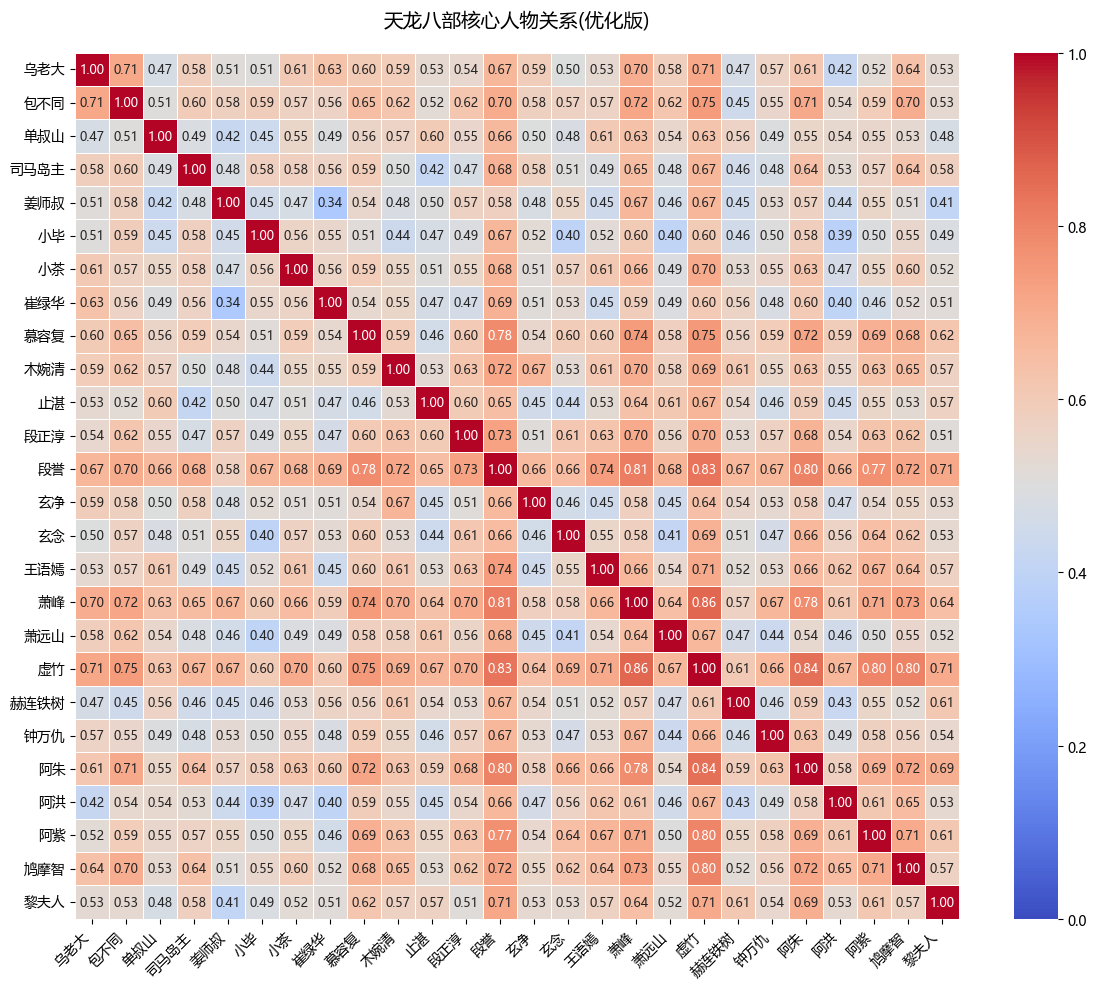

优化后的相似度矩阵已保存


In [31]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 1. 数据准备优化
def load_characters(char_file, tokenizer, word_vectors):
    """优化人物列表加载，确保名称一致且存在于词向量中"""
    with open(char_file, "r", encoding="utf-8") as f:
        raw_chars = set(line.strip() for line in f)
    

    
    valid_chars = []
    for char in raw_chars:

        if char in tokenizer.word_index:
            valid_chars.append(char)
        else:
            print(f"警告：人物'{char}'不在词向量中")
    
    return sorted(set(valid_chars))  # 确保唯一性

# 2. 相似度矩阵计算优化
def build_sim_matrix(characters, tokenizer, word_vectors):
    """构建无重复的相似度矩阵"""
    from sklearn.metrics.pairwise import cosine_similarity

    # 获取人物词向量
    char_indices = [tokenizer.word_index[char] for char in characters]
    char_vectors = word_vectors[char_indices]

    # 计算余弦相似度矩阵
    sim_matrix = cosine_similarity(char_vectors)

    # 转换为DataFrame
    matrix = pd.DataFrame(
        sim_matrix,
        index=characters,
        columns=characters
    )
    
    np.fill_diagonal(matrix.values, 1.0)  # 对角线设为1
    return matrix

# 3. 可视化优化
def plot_optimized_heatmap(matrix, top_n=65):
    """优化后的热力图绘制"""
    # 提取最相关的top_n对关系
    corr_pairs = []
    for i in range(len(matrix)):
        for j in range(i+1, len(matrix)):
            corr_pairs.append((matrix.index[i], matrix.columns[j], matrix.iloc[i,j]))
    
    top_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:top_n]
    top_chars = sorted(set([x[0] for x in top_pairs] + [x[1] for x in top_pairs]))
    
    # 创建子矩阵
    sub_matrix = matrix.loc[top_chars, top_chars]
    
    # 绘制
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    plt.title("天龙八部核心人物关系(优化版)", pad=20, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("optimized_sim_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return sub_matrix

# 主流程
if __name__ == "__main__":
    # 加载词向量和词汇表
    word_vectors = np.load('word_vectors.npy')
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    
    # 加载人物数据
    characters = load_characters("天龙八部人物.txt", tokenizer, word_vectors)
    
    # 构建相似度矩阵
    sim_matrix = build_sim_matrix(characters, tokenizer, word_vectors)
    
    # 可视化
    optimized_matrix = plot_optimized_heatmap(sim_matrix)
    
    # 保存结果
    optimized_matrix.to_csv("optimized_similarity_matrix.csv", encoding="utf-8-sig")
    print("优化后的相似度矩阵已保存")

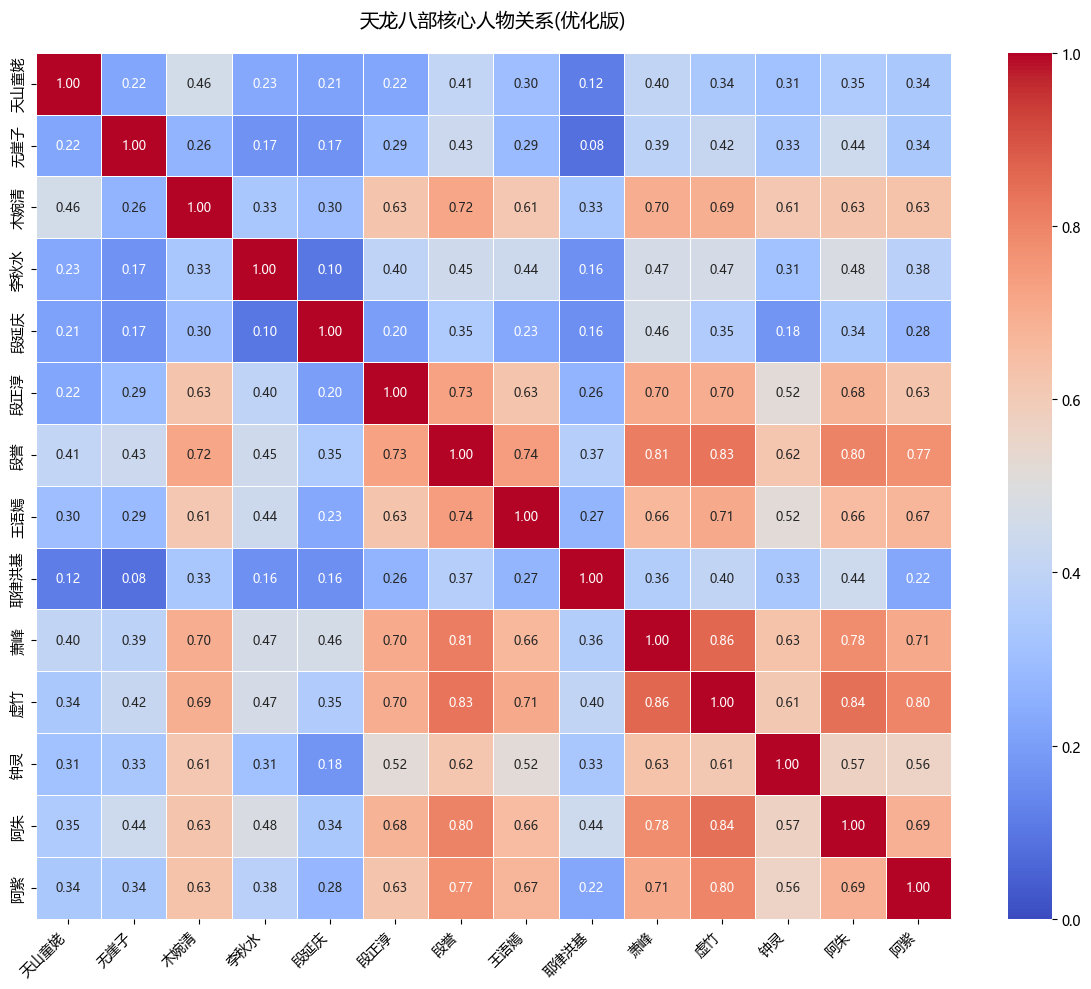

优化后的相似度矩阵已保存


In [28]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 1. 数据准备优化
def load_characters(char_file, tokenizer, word_vectors):
    """优化人物列表加载，确保名称一致且存在于词向量中"""
    with open(char_file, "r", encoding="utf-8") as f:
        raw_chars = set(line.strip() for line in f)
    

    
    valid_chars = []
    for char in raw_chars:

        if char in tokenizer.word_index:
            valid_chars.append(char)
        else:
            print(f"警告：人物'{char}'不在词向量中")
    
    return sorted(set(valid_chars))  # 确保唯一性

# 2. 相似度矩阵计算优化
def build_sim_matrix(characters, tokenizer, word_vectors):
    """构建无重复的相似度矩阵"""
    from sklearn.metrics.pairwise import cosine_similarity

    # 获取人物词向量
    char_indices = [tokenizer.word_index[char] for char in characters]
    char_vectors = word_vectors[char_indices]

    # 计算余弦相似度矩阵
    sim_matrix = cosine_similarity(char_vectors)

    # 转换为DataFrame
    matrix = pd.DataFrame(
        sim_matrix,
        index=characters,
        columns=characters
    )
    
    np.fill_diagonal(matrix.values, 1.0)  # 对角线设为1
    return matrix

# 3. 可视化优化
def plot_optimized_heatmap(matrix, top_n=200):
    """优化后的热力图绘制"""
    # 提取最相关的top_n对关系
    corr_pairs = []
    for i in range(len(matrix)):
        for j in range(i+1, len(matrix)):
            corr_pairs.append((matrix.index[i], matrix.columns[j], matrix.iloc[i,j]))
    
    top_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:top_n]
    top_chars = sorted(set([x[0] for x in top_pairs] + [x[1] for x in top_pairs]))
    
    # 创建子矩阵
    sub_matrix = matrix.loc[top_chars, top_chars]
    
    # 绘制
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0.5,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9}
    )
    plt.title("天龙八部核心人物关系(优化版)", pad=20, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("optimized_sim_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return sub_matrix

# 主流程
if __name__ == "__main__":
    # 加载词向量和词汇表
    word_vectors = np.load('word_vectors.npy')
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    
    # 加载人物数据
    characters = load_characters("天龙八部重要人物.txt", tokenizer, word_vectors)
    
    # 构建相似度矩阵
    sim_matrix = build_sim_matrix(characters, tokenizer, word_vectors)
    
    # 可视化
    optimized_matrix = plot_optimized_heatmap(sim_matrix)
    
    # 保存结果
    optimized_matrix.to_csv("optimized_similarity_matrix.csv", encoding="utf-8-sig")
    print("优化后的相似度矩阵已保存")

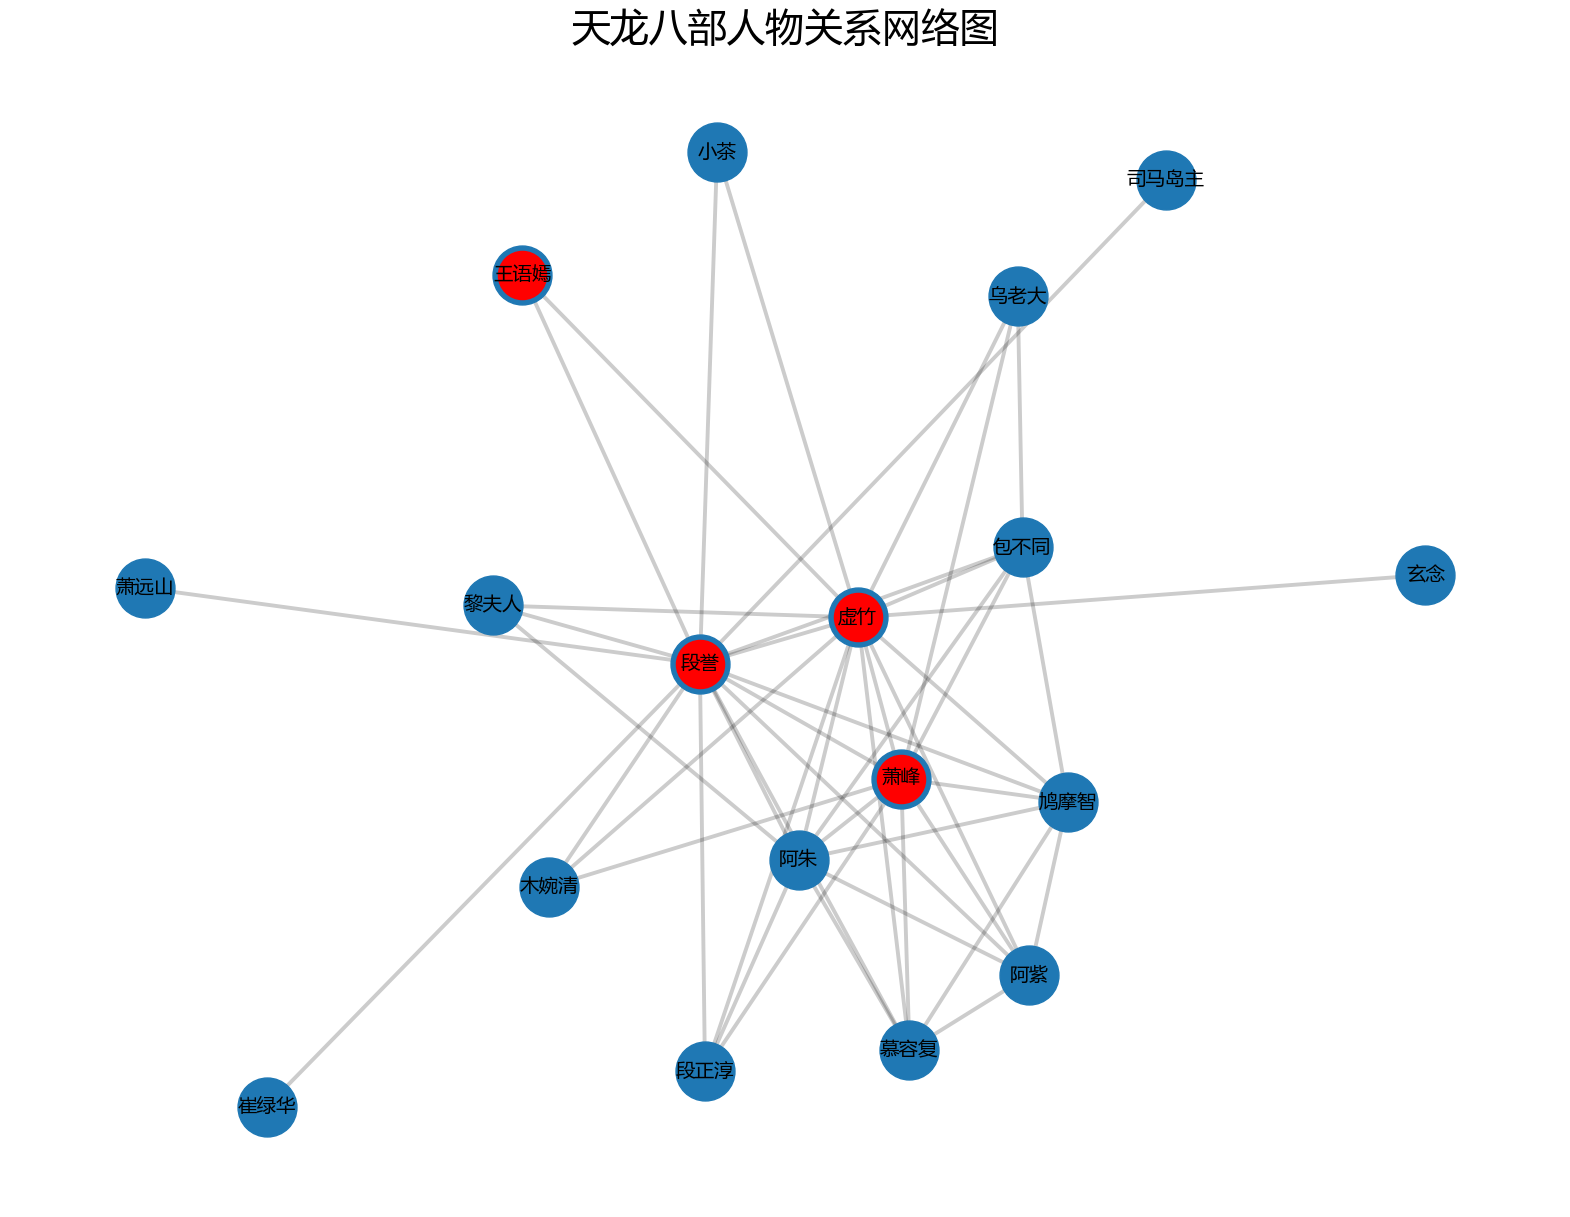

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1. 加载相似度矩阵
def load_similarity_matrix(file_path):
    """加载相似度矩阵"""
    return pd.read_csv(file_path, index_col=0)

# 2. 提取相似度高于阈值的关系
def extract_relationships(matrix, threshold_factor=0.5):
    """提取相似度高于阈值的关系"""
    relationships = []
    mean_sim = matrix.values.mean()
    std_sim = matrix.values.std()
    threshold = mean_sim + threshold_factor * std_sim

    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            sim = matrix.iloc[i, j]
            if sim > threshold:
                relationships.append((matrix.index[i], matrix.columns[j], sim))
    return relationships

# 3. 绘制人物关系网络图
def plot_character_network(relationships, important_chars=None):
    """绘制人物关系网络图"""
    # 创建关系图
    G = nx.Graph()

    # 添加边
    for char1, char2, sim in relationships:
        G.add_edge(char1, char2, weight=sim)

    # 绘制网络图
    plt.figure(figsize=(20, 15))
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # 绘制节点和边
    nx.draw_networkx_nodes(G, pos, node_size=1800, alpha=1)
    nx.draw_networkx_edges(G, pos, width=2.8, alpha=0.2)
    nx.draw_networkx_labels(G, pos, font_size=14, font_family="Microsoft YaHei")

    # 突出显示重要人物
    if important_chars:
        nx.draw_networkx_nodes(G, pos, nodelist=important_chars, node_size=1200, node_color="r")

    # 添加标题并保存
    plt.title("天龙八部人物关系网络图", fontsize=28)
    plt.axis("off")
    plt.savefig("character_network.png", dpi=300, bbox_inches="tight")
    plt.show()

# 主流程
if __name__ == "__main__":
    # 加载相似度矩阵
    sim_matrix = load_similarity_matrix("optimized_similarity_matrix.csv")

    # 提取相似度高于阈值的关系
    relationships = extract_relationships(sim_matrix, threshold_factor=0.7)

    # 定义重要人物
    important_chars = ["萧峰", "段誉", "虚竹","王语嫣"]

    # 绘制人物关系网络图
    plot_character_network(relationships, important_chars)

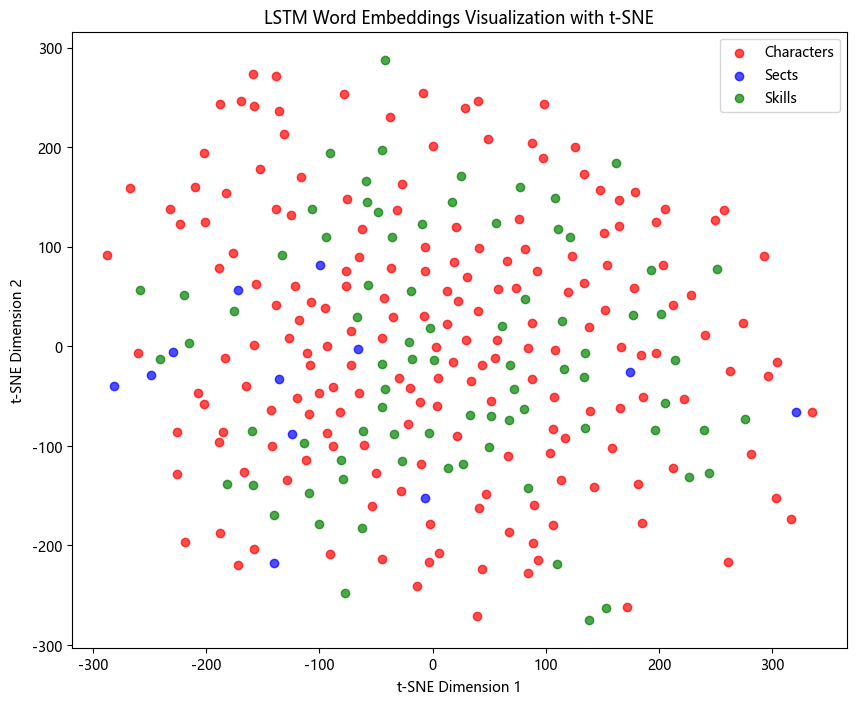

In [34]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pickle

# 加载词向量和词汇表
embedding_weights = np.load('word_vectors.npy')  # 提取词向量
with open('tokenizer.pkl', 'rb') as f:  # 加载词汇表
    tokenizer = pickle.load(f)

# 定义读取文件的函数
def read_file(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        words = [line.strip() for line in f]
    return words

# 读取三个文件
characters = read_file("天龙八部人物.txt")
sects = read_file("天龙八部门派.txt")
skills = read_file("天龙八部武功.txt")

# 获取词向量（增加索引范围检查）
def get_word_vectors(words, embedding_weights, tokenizer):
    vectors = []
    valid_words = []
    vocab_size = embedding_weights.shape[0]  # 获取词向量表的大小
    for word in words:
        if word in tokenizer.word_index:  # 检查词汇是否在词汇表中
            index = tokenizer.word_index[word]  # 获取词的索引
            if index < vocab_size:  # 检查索引是否在有效范围内
                vectors.append(embedding_weights[index])  # 获取对应的词向量
                valid_words.append(word)
    return np.array(vectors), valid_words

# 获取人物、门派、武功的词向量
char_vectors, valid_chars = get_word_vectors(characters, embedding_weights, tokenizer)
sect_vectors, valid_sects = get_word_vectors(sects, embedding_weights, tokenizer)
skill_vectors, valid_skills = get_word_vectors(skills, embedding_weights, tokenizer)

# 合并所有向量
all_vectors = np.vstack([char_vectors, sect_vectors, skill_vectors])

# 使用 t-SNE 进行降维
tsne = TSNE(n_components=2, perplexity=20, learning_rate=2000)  # 设置 t-SNE 参数
reduced_vectors = tsne.fit_transform(all_vectors)

# 准备绘图数据
char_reduced = reduced_vectors[:len(valid_chars)]
sect_reduced = reduced_vectors[len(valid_chars):len(valid_chars)+len(valid_sects)]
skill_reduced = reduced_vectors[len(valid_chars)+len(valid_sects):]

# 绘制散点图
plt.figure(figsize=(10, 8))
plt.scatter(char_reduced[:, 0], char_reduced[:, 1], c='red', label='Characters', alpha=0.7)
plt.scatter(sect_reduced[:, 0], sect_reduced[:, 1], c='blue', label='Sects', alpha=0.7)
plt.scatter(skill_reduced[:, 0], skill_reduced[:, 1], c='green', label='Skills', alpha=0.7)

plt.title('LSTM Word Embeddings Visualization with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()